# Deep Learning-Based Forecasting of Live Birth Trends in England and Wales

**Research question:** *How effectively can deep learning models forecast live birth counts from long-term demographic time-series data?*

## 1. Setup

In [154]:
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, GRU, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from statsmodels.tsa.arima.model import ARIMA as SM_ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.graphics.tsaplots import plot_acf

## 2. Load & clean the data

In [155]:
import requests

def load_birth_data():
    if os.path.exists("birthrates.csv"):
        raw = pd.read_csv("birthrates.csv")
        df = raw[raw["Country Name"] == "United Kingdom"].copy()
        df = df[["Year", "Value"]].rename(columns={"Value": "Birth Rate"})
    else:  # reproducible fallback: download the same indicator from the World Bank
        url = ("https://api.worldbank.org/v2/country/GBR/indicator/"
               "SP.DYN.CBRT.IN?format=json&per_page=200")
        rec = requests.get(url, timeout=30).json()[1]
        df = pd.DataFrame([{"Year": int(r["date"]), "Birth Rate": r["value"]}
                           for r in rec if r["value"] is not None])
    return df.sort_values("Year").set_index("Year")   # ascending & Year-indexed

df_filtered = load_birth_data()
series = df_filtered["Birth Rate"]
print(f"{len(series)} observations, {series.index.min()}-{series.index.max()}")
print(f"No missing values: {series.isnull().sum() == 0} | No duplicate years: {not series.index.duplicated().any()}")
df_filtered.tail()

64 observations, 1960-2023
No missing values: True | No duplicate years: True


,Birth Rate
Year,
2019,10.645
2020,10.204
2021,10.241
2022,10.100
2023,10.023


## 3. Exploratory Data Analysis

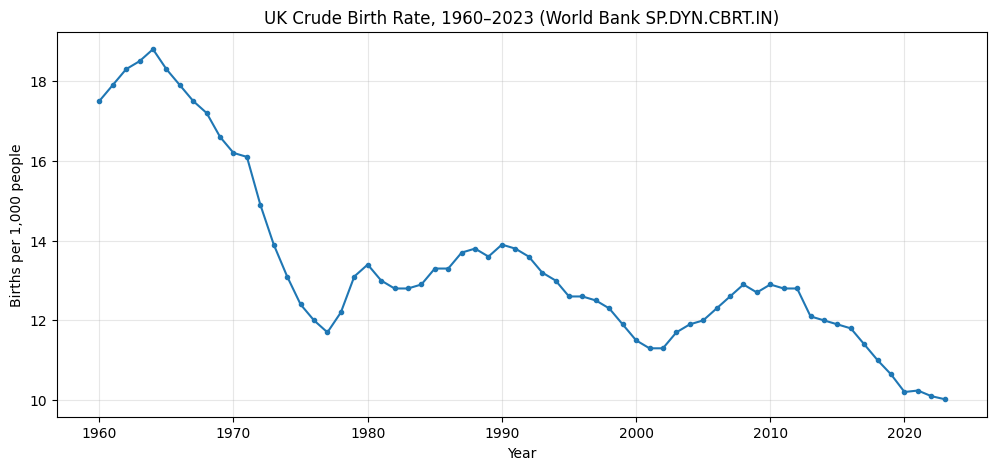

In [156]:
plt.figure(figsize=(12, 5))
plt.plot(series.index, series.values, marker="o", ms=3)
plt.title("UK Crude Birth Rate, 1960–2023 (World Bank SP.DYN.CBRT.IN)")
plt.xlabel("Year"); plt.ylabel("Births per 1,000 people"); plt.grid(alpha=.3)
plt.show()

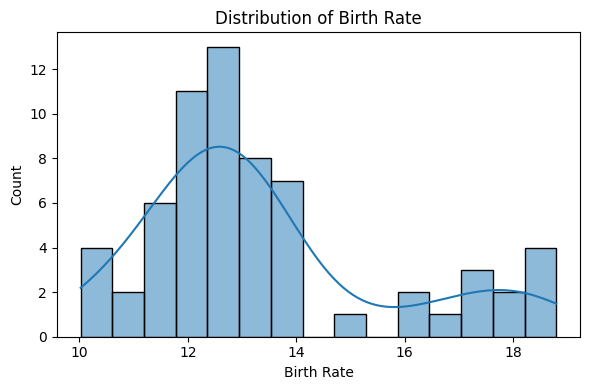

In [157]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(series, bins=15, kde=True, ax=ax)
ax.set_title("Distribution of Birth Rate")
plt.tight_layout()
plt.show()

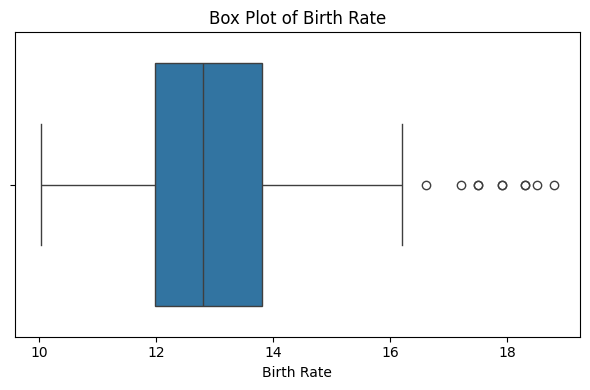

In [158]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
sns.boxplot(x=series, ax=ax)
ax.set_title("Box Plot of Birth Rate")
plt.tight_layout()
plt.show()

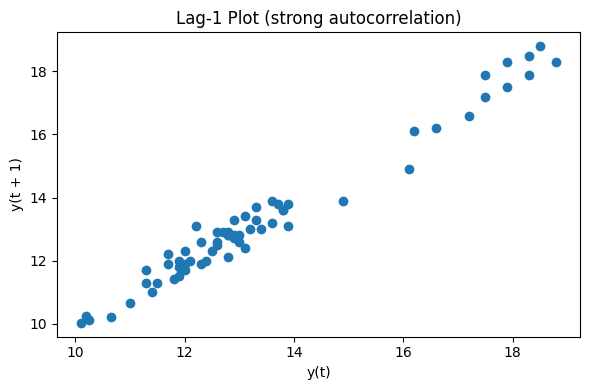

In [159]:
fig, ax = plt.subplots(figsize=(6, 4))
pd.plotting.lag_plot(series, lag=1, ax=ax)
ax.set_title("Lag-1 Plot (strong autocorrelation)")
plt.tight_layout()
plt.show()

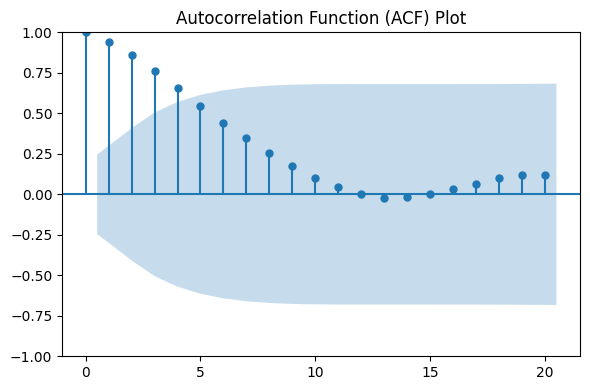

In [160]:
fig, ax = plt.subplots(figsize=(6, 4))
plot_acf(series, lags=20, ax=ax)
ax.set_title("Autocorrelation Function (ACF) Plot")
plt.tight_layout()
plt.show()

In [161]:
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
tf.keras.utils.set_random_seed(SEED)          # python + numpy + tensorflow
tf.config.experimental.enable_op_determinism() # forces deterministic TF ops

def lock_seeds(seed=SEED):
    """Call at the START of every cell that trains a model —
    this is what keeps results identical across repeated runs."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)

print("TensorFlow:", tf.__version__, "| deterministic mode ON")

TensorFlow: 2.20.0 | deterministic mode ON


## 4. Train/test split & windowing utilities

In [173]:
SPLIT_YEAR, LOOKBACK, HORIZON = 2011, 5, 7

train = series[series.index < SPLIT_YEAR]     # 1960–2010 (51 pts)
test  = series[series.index >= SPLIT_YEAR]    # 2011–2023 (13 pts)
y_test_actual = test.values
print(f"Train: {train.index.min()}-{train.index.max()} ({len(train)})")
print(f"Test : {test.index.min()}-{test.index.max()} ({len(test)})")

def make_windows(arr, lookback=LOOKBACK):
    X, y = [], []
    for i in range(lookback, len(arr)):
        X.append(arr[i - lookback:i]); y.append(arr[i])
    return np.array(X), np.array(y)

def evaluate_model(actual, pred, name):
    mae  = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    r2   = r2_score(actual, pred)
    mape = np.mean(np.abs((actual - pred) / actual)) * 100
    return {"Model": name, "MAE": round(mae, 4), "RMSE": round(rmse, 4),
            "R2 Score": round(r2, 4), "MAPE (%)": round(mape, 4)}

all_results, all_preds = [], {}
all_histories = {} # New: Dictionary to store training histories

Train: 1960-2010 (51)
Test : 2011-2023 (13)


In [163]:
diff = series.diff().dropna()
train_d = diff[diff.index < SPLIT_YEAR]

scaler_d = MinMaxScaler()
train_d_scaled = scaler_d.fit_transform(train_d.values.reshape(-1, 1)).flatten()
full_d_scaled  = scaler_d.transform(diff.values.reshape(-1, 1)).flatten()

Xd_train, yd_train = make_windows(train_d_scaled)
Xd_train = Xd_train.reshape(-1, LOOKBACK, 1)
Xd_test, _ = make_windows(full_d_scaled[len(train_d) - LOOKBACK:])
Xd_test = Xd_test.reshape(-1, LOOKBACK, 1)

prev_levels = series.shift(1).loc[test.index].values
print("Train windows:", Xd_train.shape, "| Test windows:", Xd_test.shape)

Train windows: (45, 5, 1) | Test windows: (13, 5, 1)


##  Model training



In [174]:
def build_net(layer_cls):
    net = Sequential([
        Input(shape=(LOOKBACK, 1)),
        layer_cls(64, activation="tanh"), # Increased units from 32 to 64
        Dropout(0.1),
        Dense(1),
    ])
    net.compile(optimizer=Adam(learning_rate=0.001), loss="mse") # Decreased learning rate from 0.005 to 0.001
    return net

def train_ensemble(layer_cls, n_members=5):
    members, changes, histories = [], [], [] # New: Collect histories
    for s in range(n_members):
        lock_seeds(SEED + s)
        net = build_net(layer_cls)
        history = net.fit(Xd_train, yd_train, epochs=500, batch_size=4,
                validation_split=0.15,
                callbacks=[EarlyStopping(monitor="val_loss", patience=60,
                                         restore_best_weights=True)],
                verbose=0)
        members.append(net)
        changes.append(scaler_d.inverse_transform(
            net.predict(Xd_test, verbose=0)).flatten())
        histories.append(history) # New: Store history
    pred = prev_levels + np.mean(changes, axis=0)
    return members, pred, histories # New: Return histories

### Model 1 — GRU

In [175]:
gru_models, gru_pred, gru_histories = train_ensemble(GRU) # New: Capture histories
gru_results = evaluate_model(y_test_actual, gru_pred, "GRU")
all_results.append(gru_results); all_preds["GRU"] = gru_pred
all_histories["GRU"] = gru_histories[0] # New: Store first history for plotting
gru_results

{'Model': 'GRU',
 'MAE': 0.2414,
 'RMSE': np.float64(0.3176),
 'R2 Score': 0.8922,
 'MAPE (%)': np.float64(2.1184)}

### Model 2 — LSTM

In [176]:
lstm_models, lstm_pred, lstm_histories = train_ensemble(LSTM) # New: Capture histories
lstm_results = evaluate_model(y_test_actual, lstm_pred, "LSTM")
all_results.append(lstm_results); all_preds["LSTM"] = lstm_pred
all_histories["LSTM"] = lstm_histories[0] # New: Store first history for plotting
lstm_results

{'Model': 'LSTM',
 'MAE': 0.238,
 'RMSE': np.float64(0.3147),
 'R2 Score': 0.8942,
 'MAPE (%)': np.float64(2.0788)}

### Model 5 — CNN

In [177]:
def build_cnn_model():
    net = Sequential([
        Input(shape=(LOOKBACK, 1)),
        tf.keras.layers.Conv1D(filters=64, kernel_size=2, activation='relu'), # Increased filters from 32 to 64
        tf.keras.layers.Flatten(),
        Dense(1),
    ])
    net.compile(optimizer=Adam(learning_rate=0.001), loss="mse") # Decreased learning rate from 0.005 to 0.001
    return net

# CNN ensemble training (adapted from train_ensemble)
cnn_members, cnn_changes, cnn_histories = [], [], [] # New: Collect cnn_histories
n_members = 5 # Use the same number of ensemble members as GRU/LSTM
for s in range(n_members):
    lock_seeds(SEED + s)
    net = build_cnn_model()
    history = net.fit(Xd_train, yd_train, epochs=500, batch_size=4,
            validation_split=0.15,
            callbacks=[EarlyStopping(monitor="val_loss", patience=60,
                                     restore_best_weights=True)],
            verbose=0)
    cnn_members.append(net)
    cnn_changes.append(scaler_d.inverse_transform(
        net.predict(Xd_test, verbose=0)).flatten())
    cnn_histories.append(history) # New: Store history
cnn_pred = prev_levels + np.mean(cnn_changes, axis=0)
cnn_results = evaluate_model(y_test_actual, cnn_pred, "CNN")
all_results.append(cnn_results); all_preds["CNN"] = cnn_pred
all_histories["CNN"] = cnn_histories[0] # New: Store first history for plotting
cnn_results

{'Model': 'CNN',
 'MAE': 0.1957,
 'RMSE': np.float64(0.2776),
 'R2 Score': 0.9176,
 'MAPE (%)': np.float64(1.7268)}

## Model Training Loss Curves

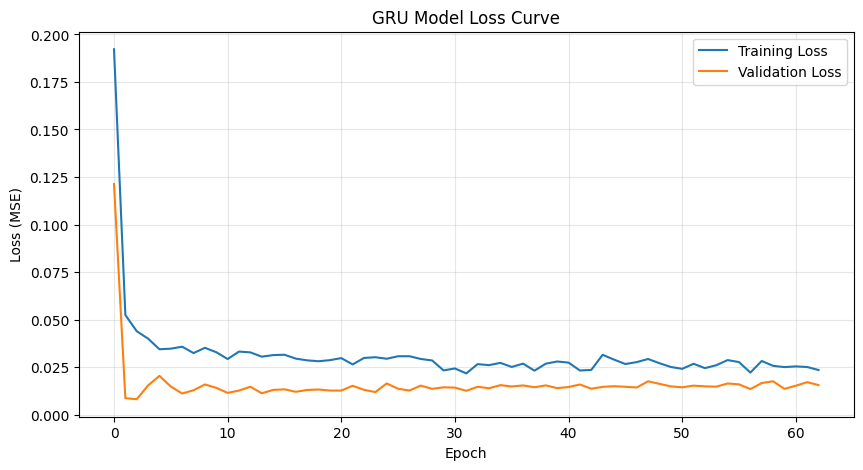

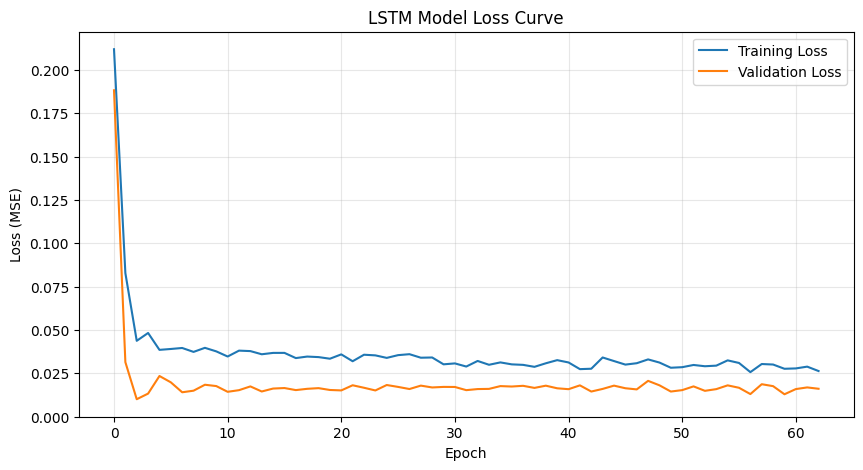

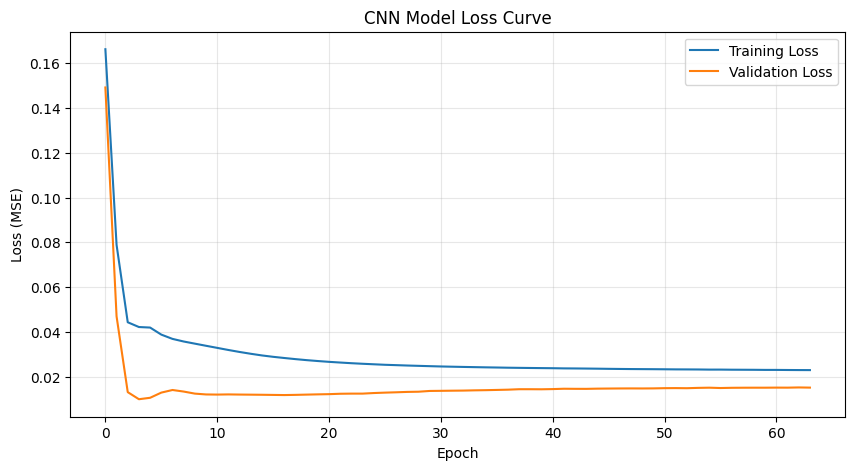

In [178]:
for model_name, history in all_histories.items():
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Training Loss')
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} Model Loss Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

In [168]:
if all_results:
    results_df = pd.DataFrame(all_results).set_index("Model").sort_values("RMSE")
    print("Final Model Evaluation — Test set 2011–2023")
    display(results_df)
else:
    print("No model results available. Please run the model training cells first (GRU, LSTM, CNN).")

Final Model Evaluation — Test set 2011–2023


,MAE,RMSE,R2 Score,MAPE (%)
Model,,,,
CNN,0.1957,0.2776,0.9176,1.7268
LSTM,0.2380,0.3147,0.8942,2.0788
GRU,0.2414,0.3176,0.8922,2.1184


## 7. Final evaluation

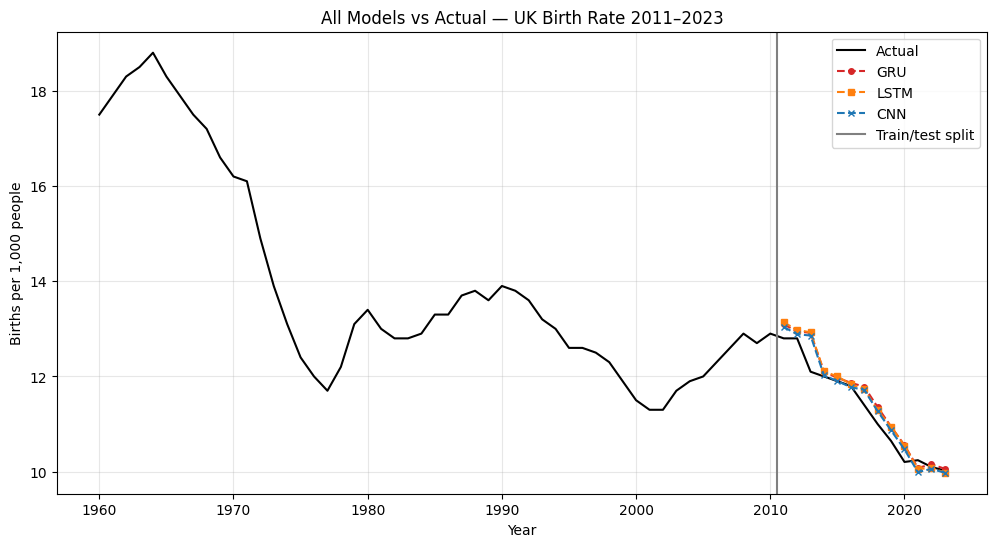

In [169]:
plt.figure(figsize=(12, 6))
plt.plot(series.index, series.values, color="black", lw=1.5, label="Actual")
styles = {"GRU": ("o--","tab:red"), "LSTM": ("s--","tab:orange"),
          "ARIMA": ("^--","tab:purple"), "Holt damped trend": ("d--","tab:green"),
          "CNN": ("x--","tab:blue")} # Added CNN style
for name, pred in all_preds.items():
    if name in styles: # Only plot if a style is defined
        fmt, col = styles[name]
        plt.plot(test.index, pred, fmt, color=col, ms=4, label=name)
plt.axvline(SPLIT_YEAR - 0.5, ls="-", color="gray", label="Train/test split") # Changed to solid gray line
plt.title("All Models vs Actual — UK Birth Rate 2011–2023")
plt.xlabel("Year"); plt.ylabel("Births per 1,000 people")
plt.legend(); plt.grid(alpha=.3); plt.show()

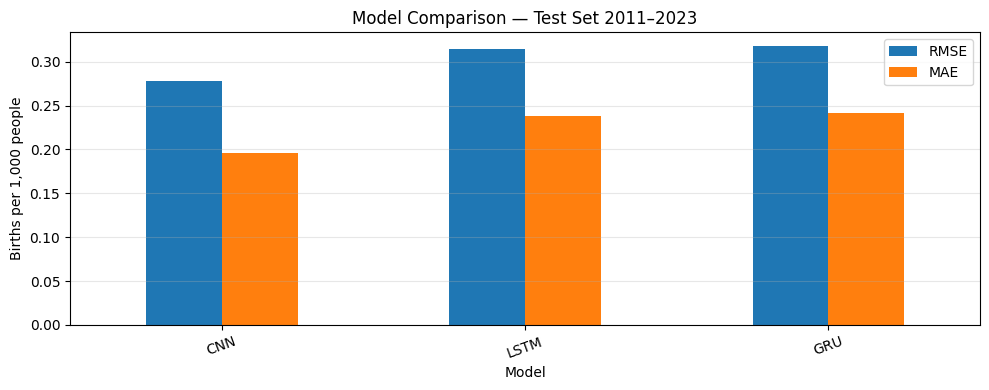

In [170]:
results_df[["RMSE", "MAE"]].plot(kind="bar", figsize=(10, 4), rot=20)
plt.title("Model Comparison — Test Set 2011–2023")
plt.ylabel("Births per 1,000 people"); plt.grid(axis="y", alpha=.3)
plt.tight_layout(); plt.show()

In [171]:
window = list(full_d_scaled[-LOOKBACK:])
level = series.iloc[-1]
forecast = []
for _ in range(HORIZON):
    x = np.array(window[-LOOKBACK:]).reshape(1, LOOKBACK, 1)
    p_scaled = np.mean([m.predict(x, verbose=0)[0, 0] for m in gru_models])
    change = scaler_d.inverse_transform([[p_scaled]])[0, 0]
    level += change
    forecast.append(level)
    window.append(p_scaled)

future_years = np.arange(series.index.max() + 1, series.index.max() + 1 + HORIZON)
forecast_df = pd.DataFrame({"Year": future_years,
                            "Forecast Birth Rate": np.round(forecast, 3)}).set_index("Year")
forecast_df

,Forecast Birth Rate
Year,
2024,10.027
2025,10.071
2026,10.159
2027,10.267
2028,10.404
2029,10.564
2030,10.743


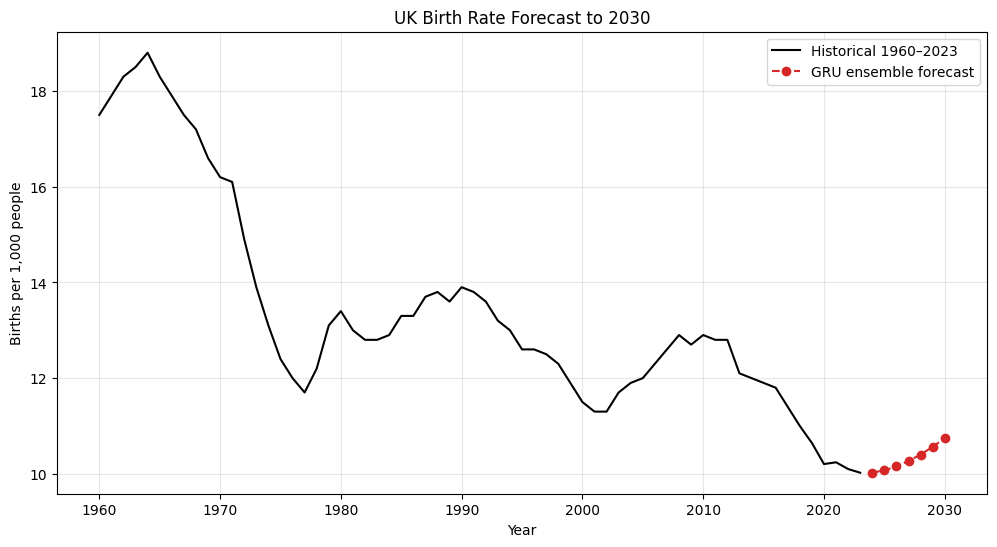

In [172]:
plt.figure(figsize=(12, 6))
plt.plot(series.index, series.values, color="black", label="Historical 1960–2023")
plt.plot(future_years, forecast, "o--", color="tab:red", label="GRU ensemble forecast")
plt.title("UK Birth Rate Forecast to 2030")
plt.xlabel("Year"); plt.ylabel("Births per 1,000 people")
plt.legend(); plt.grid(alpha=.3); plt.show()